In [2]:
import os
import math
import torch
from torch.nn.functional import softplus
from datetime import datetime
from tensorboardX import SummaryWriter
from nn.neural_network_dens import NeuralNetwork
from training.parse_command_line_arguments import parse_command_line_arguments
from training.util import generate_id, empty_error_dict, compute_error_dict
from training.grid_density_dataset import AtomsDensityDataNpy
from training.hamiltonian_dataset import seeded_random_split
from training.exponential_moving_average import ExponentialMovingAverage
from training.lookahead import Lookahead
from training.batch_loader import BatchLoader
from nn.modules.spherical_harmonics_expansion import SphericalHarmonicsExpansion
import numpy as np
import time
%load_ext autoreload
%autoreload 2

In [10]:
directory = '2020-05-12_Lo2D2pG4'  # load directory name
#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False

In [11]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

args.num_workers = 0

dataset = AtomsDensityDataNpy(args.np_dataset, args.dens_dataset, args.orbitals_file,
                              args.density_subsamples, required_properties=['density'],
                              center_positions=False, dtype=args.dtype)


# determine weights of different quantities for scaling loss
sampler = torch.utils.data.BatchSampler(torch.utils.data.SequentialSampler(dataset),
                                              batch_size=6, drop_last=False)

data_loader = BatchLoader(dataset, batch_sampler=sampler,
                                num_workers=args.num_workers, pin_memory=use_gpu)


loading density from/home/mihail/data/water_rot/full_densities.npy...
loading atoms fromdatasets/h2o_overlap_static.npy...
Starting atomsdata density init
Some variables
dataset shape (18, 1953125)
finished init


In [12]:
# define model
equiv_model = NeuralNetwork(
    orbitals=dataset.orbitals,
    order=args.order,
    num_features=args.num_features,
    num_basis_functions=args.num_basis_functions,
    num_modules=args.num_modules,
    num_residual_pre_x=args.num_residual_pre_x,
    num_residual_post_x=args.num_residual_post_x,
    num_residual_pre_vi=args.num_residual_pre_vi,
    num_residual_pre_vj=args.num_residual_pre_vj,
    num_residual_post_v=args.num_residual_post_v,
    num_residual_output=args.num_residual_output,
    num_radial_components=args.num_radial_components,
    basis_functions=args.basis_functions,
    cutoff=args.cutoff,
    activation=args.activation)
expansion_model = SphericalHarmonicsExpansion(equiv_model.density_orbitals)


# convert the model to the correct dtype
equiv_model.to(args.dtype)
expansion_model.to(args.dtype)

# send model to GPU (if use_gpu is True)
if use_gpu:
    equiv_model.cuda()
    expansion_model.cuda()


density orbital basis [[(8, 10, 0), (8, 12, 1), (8, 9, 2), (8, 3, 3)], [(1, 4, 0), (1, 3, 1), (1, 1, 2)], [(1, 4, 0), (1, 3, 1), (1, 1, 2)]]
cg_matrix shape torch.Size([121, 121, 121])
L_counts [14, 15, 10, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0]
L_dict {(8, 0): range(0, 10), (8, 1): range(0, 12), (8, 2): range(0, 9), (8, 3): range(0, 3), (1, 0): range(10, 14), (1, 1): range(12, 15), (1, 2): range(9, 10)}
max lcounts 15


In [13]:
equiv_module = equiv_model
expansion_module = expansion_model

# for keeping an exponential moving average of the model parameters (usually leads to better models)
if checkpoint is not None:  # no checkpoint is specified
    step = checkpoint['step']
    epoch = checkpoint['epoch']
    best_errors = checkpoint['best_errors']
    valid_errors = checkpoint['valid_errors']
    equiv_module.load_state_dict(checkpoint['model_state_dict'])
# or initialize step / epoch to 0 and errors to infinity
else:
    step = 0
    epoch = 0
    best_errors = empty_error_dict(loss_weights, fill_value=math.inf)
    valid_errors = empty_error_dict(loss_weights, fill_value=math.inf)



In [134]:
"""
###############################################
################ TRAINING LOOP ################
###############################################
"""
equiv_model.eval()
expansion_model.eval()
iterator = iter(data_loader)
step = 0
while step < 3:
    # get the next batch
    try:
        data = next(iterator)
    except StopIteration:
        epoch += 1
        iterator = iter(data_loader)
        continue
    # print('dataset dtype', dataset.dtype)
    # print('positions dtype', data['positions'].dtype)
    # print('positions dtype', data['coords_space'].dtype)
    print('step', step)
    # send data to GPU
    if use_gpu:
        for key in data.keys():
            if isinstance(data[key], torch.Tensor):
                data[key] = data[key].cuda()
    coeffs = equiv_model(R=data['positions'])
    print('pos shape', data['positions'].shape)
    print('coods shape', data['coords_space'].shape)
    predictions = expansion_model(data['coords_space'], data['positions'],
                                  coeffs['spherical_coeffs'],
                                  coeffs['radial_width'],
                                  coeffs['radial_scale'])
    
    print('data_positions', data['positions'])
    print('data_dens', data['density'])
    print('pred_dens', predictions['density'])
    print('data_idx', data['idx'])
    
    mae = torch.mean(torch.abs(predictions['density']/1000 - data['density']), dim=-1)
    print('MAE', mae)
    step += 1

step 0
pos shape torch.Size([6, 3, 3])
coods shape torch.Size([1, 125000, 3])
data_positions tensor([[[-4.8513e-02, -4.8513e-02,  0.0000e+00],
         [ 9.2076e-01, -1.5076e-01,  0.0000e+00],
         [-1.5076e-01,  9.2076e-01,  0.0000e+00]],

        [[-4.8513e-02, -3.4304e-02, -3.4304e-02],
         [ 9.2076e-01, -1.0661e-01, -1.0661e-01],
         [-1.5076e-01,  6.5108e-01,  6.5108e-01]],

        [[-4.8513e-02, -5.5953e-18, -4.8513e-02],
         [ 9.2076e-01, -5.5953e-18, -1.5076e-01],
         [-1.5076e-01,  9.4405e-17,  9.2076e-01]],

        [[-4.8513e-02, -4.8513e-02,  0.0000e+00],
         [ 9.2076e-01, -1.5076e-01,  0.0000e+00],
         [-1.5076e-01,  9.2076e-01,  0.0000e+00]],

        [[-4.8513e-02, -4.8513e-02,  1.1191e-13],
         [ 7.6384e-01,  6.1588e-03, -5.3576e-01],
         [ 6.1588e-03,  7.6384e-01,  5.3576e-01]],

        [[-4.8513e-02, -4.8513e-02,  1.5826e-13],
         [ 3.8500e-01,  3.8500e-01, -7.5768e-01],
         [ 3.8500e-01,  3.8500e-01,  7.5768e-01

<IPython.core.display.Javascript object>


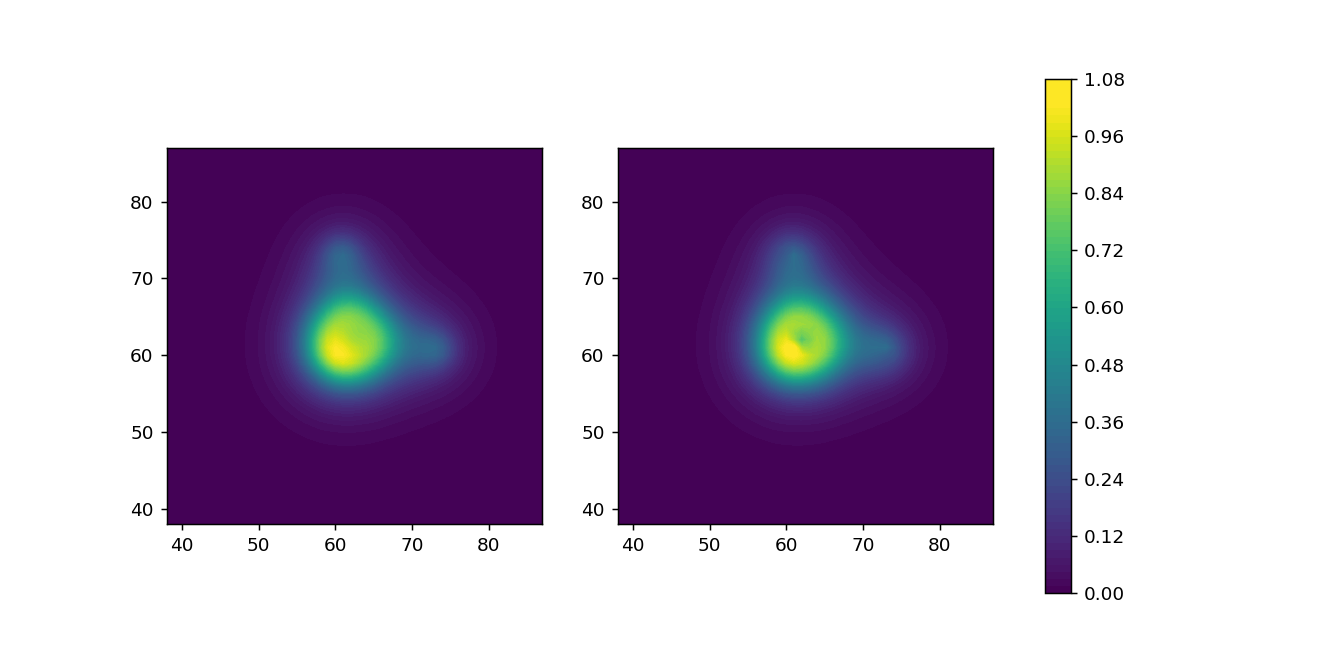

idx [ 598562  614187  629812 ... 1339062 1354687 1370312]
coords space shape torch.Size([1, 2500, 3])
pos shape torch.Size([1, 3, 3])
torch.Size([1, 2500])


In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook
sample = 0
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
dens = dataset.density_dset[sample]
x, y  = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38)
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 62
idx = np.ravel_multi_index((x_f, y_f, z_f), (125, 125, 125))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = torch.from_numpy((indices - 62) * (20 / 125)) * 0.529117
coords_space = coords_space.unsqueeze(0).type(args.dtype)
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

positions = dataset[[sample]]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()

print('pos shape', dataset[[sample]]['positions'].shape)
coeffs = equiv_model(R=positions)
pred_dens = expansion_model(coords_space, positions,
                            coeffs['spherical_coeffs'],
                            coeffs['radial_width'],
                            coeffs['radial_scale'], eval_atoms=[0, 1, 2], eval_L=[0, 1, 2, 3])



print(pred_dens['density'].shape)

p_dens = pred_dens['density'].reshape(50, 50).cpu().data.numpy() / 1000

ax2 = fig.add_subplot(122)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
plt.show()

In [20]:
print('pos', positions)

pos tensor([[[-0.0485, -0.0485,  0.0000],
         [ 0.9208, -0.1508,  0.0000],
         [-0.1508,  0.9208,  0.0000]]])


In [136]:
from nn.spherical_harmonics import spherical_harmonics
import torch.nn as nn

class CoeffsModel(nn.Module):
    def __init__(self, orbitals, spherical_coeffs, radial_width, radial_scale):
        super().__init__()
        self.orbitals = orbitals
        self.order_max = 0

        for i in range(len(self.orbitals)):
            for z, l in self.orbitals[i]:
                if l > self.order_max:
                    self.order_max = l
        
        self.spherical_coeffs = [None] * len(self.orbitals)
        self.radial_width = [None] * len(self.orbitals)
        self.radial_scale = [None] * len(self.orbitals)
        sph_base = 'spherical_coeffs'
        rad_w_base = 'radial_width'
        rad_s_base = 'radial_scale'
        for i in range(len(self.orbitals)):
            z = self.orbitals[i][0][0]
            self.spherical_coeffs[i] = {}
            self.radial_width[i] = {}
            self.radial_scale[i] = {}
            for n, orb in enumerate(self.orbitals[i]):
                L = orb[1]
                key = (z, n, L)
                self.spherical_coeffs[i][key] = nn.Parameter(torch.clone(spherical_coeffs[i][key]))
                sph_name = sph_base + '_{}_{}_{}_{}'.format(i, z, n, L)
                self.register_parameter(sph_name, self.spherical_coeffs[i][key])
                self.radial_width[i][key] = nn.Parameter(torch.clone(radial_width[i][key]))
                rad_w_name = rad_w_base + '_{}_{}_{}_{}'.format(i, z, n, L)
                self.register_parameter(rad_w_name, self.radial_width[i][key])
                self.radial_scale[i][key] = nn.Parameter(torch.clone(radial_scale[i][key]))
                rad_s_name = rad_s_base + '_{}_{}_{}_{}'.format(i, z, n, L)
                self.register_parameter(rad_s_name, self.radial_scale[i][key])
                
            

    def forward(self, coords, atom_R, eval_atoms=None, eval_L=None):
        # print('orbitals', self.orbitals)
        # print('coords shape', coords.shape)
        # print('atom_R shape', atom_R.shape)
        # print('rad_width keys', rad_width[0].keys())
        # print('rad_scale keys', rad_scale[0].keys())
        if eval_atoms is None:
            eval_atoms = list(range(len(self.orbitals)))
        if eval_L is None:
            eval_L = list(range(self.order_max))
        result = {'density': 0}
        for i in eval_atoms:
            z = self.orbitals[i][0][0]
            d, u = calculate_distances_and_directions(coords, center=atom_R[:, [i]])
            s = spherical_harmonics(self.order_max, u)
            for n, orb in enumerate(self.orbitals[i]):
                L = orb[1]
                if L not in eval_L:
                    continue
                key = (z, n, L)
                width = self.radial_width[i][key]
                scale = self.radial_scale[i][key]
                # print('s shape', s[L].shape)
                # print('sph shape', sph_coeffs[i][key].shape)
                sph = s[L] * self.spherical_coeffs[i][key]
                rbf = gaussian_rbf(d, width, scale)
                # print('sph shape', sph.shape)
                # print('rbf shape', rbf.shape)
                result['density'] += torch.sum(rbf * sph, dim=-1)
        result['density'] = result['density']**2

        return result


def gaussian_rbf(r, width, scale):
    # print('scale shape', scale.shape)
    # print('width shape', width.shape)
    # print('r shape', r.shape)
    rbf = scale * torch.exp(-width * (r)**2)
    return torch.sum(rbf, dim=-1, keepdim=True)


def calculate_distances_and_directions(r, center=None):
    if center is None:
        center = 0
    # print('r', r.type())
    # print('center', center.type())

    r = r - center
    d = torch.norm(r, dim=-1, keepdim=True)
    u = r / d
    return d, u


<IPython.core.display.Javascript object>


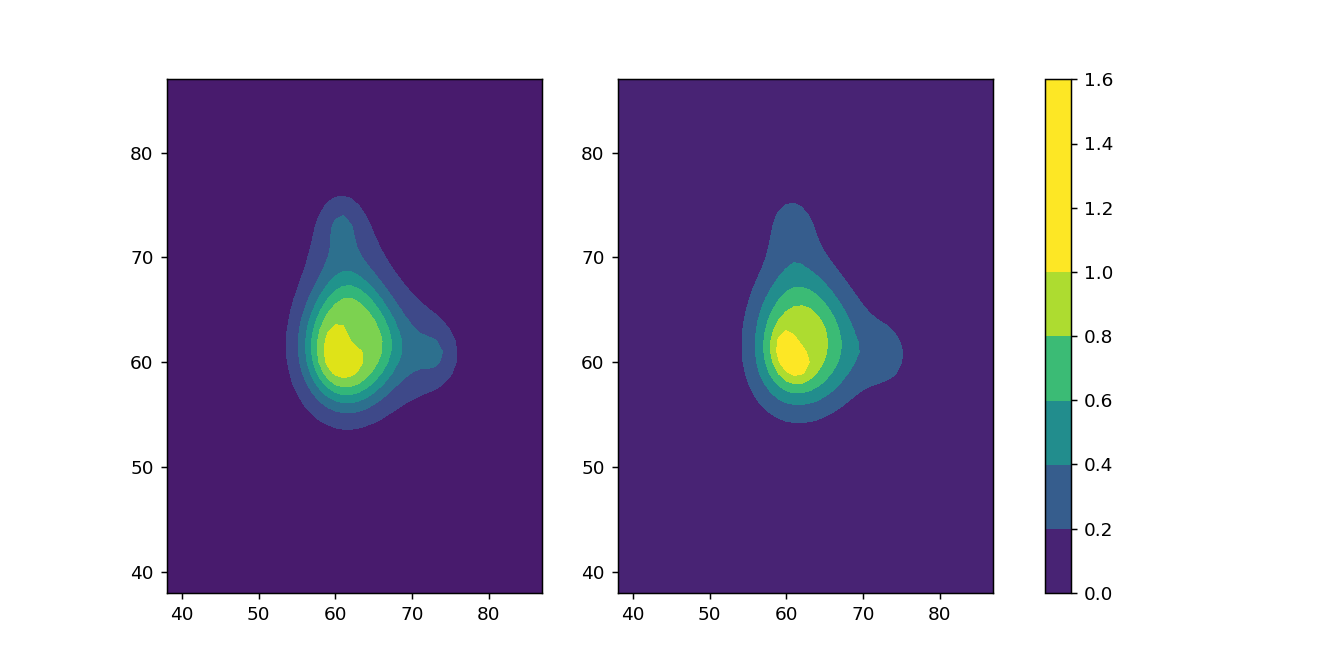

idx [ 598562  614187  629812 ... 1339062 1354687 1370312]
coords space shape torch.Size([1, 2500, 3])
pos shape torch.Size([1, 3, 3])
torch.Size([1, 2500])


In [153]:
sample = 0
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
dens = dataset.density_dset[sample]
x, y  = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38)
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 62
idx = np.ravel_multi_index((x_f, y_f, z_f), (125, 125, 125))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))
positions = dataset[[sample]]['positions']
if args.use_gpu:
    positions = positions.cuda()
    coords_space = coords_space.cuda()
coeffs = equiv_model(R=positions)

coeffs_model = CoeffsModel(dataset.orbitals, coeffs['spherical_coeffs'],
                           coeffs['radial_width'], coeffs['radial_scale'])

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = torch.from_numpy((indices - 62) * (20 / 125)) * 0.529117
coords_space = coords_space.unsqueeze(0).type(args.dtype)
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax)


print('pos shape', dataset[[sample]]['positions'].shape)
pred_dens = coeffs_model(coords_space, positions, eval_atoms=[0, 1, 2], eval_L=[0, 1, 2, 3])


print(pred_dens['density'].shape)

p_dens = pred_dens['density'].reshape(50, 50).cpu().data.numpy() / 1000

ax2 = fig.add_subplot(122)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax)

fig.colorbar(c2, ax=[ax1, ax2])
plt.show()

In [155]:
optimizer = torch.optim.SGD(coeffs_model.parameters(), lr=(1e-6), nesterov=True, momentum=0.6)
# optimizer = torch.optim.Adam(coeffs_model.parameters(), lr=1e-4, eps=args.epsilon, betas=(
#    args.beta1, args.beta2), weight_decay=0.0)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=args.decay_factor, patience=100, verbose=1)

dens3d = dataset[[sample]]['density']
print(dens3d.shape)
for i in range(100000):
    #print('coords space shape', dataset[[sample]]['coords_space'].shape)
    pred_dens = coeffs_model(dataset[[sample]]['coords_space'], positions, eval_atoms=[0, 1, 2], eval_L=[0, 1, 2, 3])
    # print('dens target', dens_target.shape)
    # print('dens target nan', torch.sum(torch.isnan(dens_target)))
    # print('dens pred', pred_dens['density'].shape)
    # print('dens pred nan', torch.sum(torch.isnan(pred_dens['density'])))
    loss = torch.sqrt(torch.mean((dens3d*1000 - pred_dens['density'])**2))
    print('loss', loss)
    loss.backward()
    optimizer.step()
    scheduler.step(loss)

torch.Size([1, 125000])
loss tensor(5.7634, grad_fn=<SqrtBackward>)
loss tensor(5.7984, grad_fn=<SqrtBackward>)
loss tensor(5.8624, grad_fn=<SqrtBackward>)
loss tensor(5.9615, grad_fn=<SqrtBackward>)
loss tensor(6.0962, grad_fn=<SqrtBackward>)
loss tensor(6.2640, grad_fn=<SqrtBackward>)
loss tensor(6.4598, grad_fn=<SqrtBackward>)
loss tensor(6.6759, grad_fn=<SqrtBackward>)
loss tensor(6.9013, grad_fn=<SqrtBackward>)
loss tensor(7.1221, grad_fn=<SqrtBackward>)
loss tensor(7.3221, grad_fn=<SqrtBackward>)
loss tensor(7.4848, grad_fn=<SqrtBackward>)
loss tensor(7.5949, grad_fn=<SqrtBackward>)
loss tensor(7.6397, grad_fn=<SqrtBackward>)
loss tensor(7.6104, grad_fn=<SqrtBackward>)
loss tensor(7.5034, grad_fn=<SqrtBackward>)
loss tensor(7.3215, grad_fn=<SqrtBackward>)
loss tensor(7.0747, grad_fn=<SqrtBackward>)
loss tensor(6.7824, grad_fn=<SqrtBackward>)
loss tensor(6.4742, grad_fn=<SqrtBackward>)
loss tensor(6.1904, grad_fn=<SqrtBackward>)
loss tensor(5.9787, grad_fn=<SqrtBackward>)
loss ten

KeyboardInterrupt: 